# YZM0206 Proje - DenseNet121 Transfer Learning ve Fine-tuning

Bu notebookta EuroSAT RGB veri seti üzerinde DenseNet121 modeli kullanılarak transfer learning ve fine-tuning uygulanmıştır. Projenin bu bölümü, hazır ağırlıklı daha güçlü bir CNN mimarisinin seçilen veri setine nasıl uyarlandığını göstermek için hazırlanmıştır.

DenseNet121, katmanlar arasında yoğun bağlantılar kullanan bir mimaridir. Bu yapı sayesinde önceki katmanlarda öğrenilen özellikler sonraki katmanlara doğrudan aktarılır. Uydu görüntülerinde renk, doku, bitki örtüsü ve yerleşim örüntüleri gibi ayrıntılar önemli olduğu için DenseNet121 bu proje için anlamlı bir karşılaştırma modelidir.

Bu notebookun projedeki yeri:

1. İlk notebookta veri seti incelenmiş ve sabit train / validation / test ayrımı oluşturulmuştur.
2. İkinci notebookta hazır ağırlık kullanmadan baseline CNN modeli eğitilmiştir.
3. Üçüncü notebookta MobileNetV2 ile ilk transfer learning deneyi yapılmıştır.
4. Bu notebookta DenseNet121 ile daha güçlü bir transfer learning deneyi yapılmıştır.

Bu çalışma iki aşamadan oluşur:

1. Feature extraction: DenseNet121 tabanı dondurulur ve sadece yeni sınıflandırma katmanları eğitilir.
2. Fine-tuning: DenseNet121 tabanının son katmanlarından bir kısmı düşük learning rate ile tekrar eğitilir.

Amaç, DenseNet121'in hazır ImageNet ağırlıklarının EuroSAT sınıflandırmasında ne kadar fayda sağladığını ve fine-tuning adımının performansı nasıl etkilediğini ölçmektir.

## Kütüphaneler ve proje dizinleri

Bu bölümde model eğitimi, değerlendirme ve görselleştirme için gerekli kütüphaneler içe aktarılmıştır. Rastgelelik kontrolü için seed değeri sabitlenmiştir. Böylece veri okuma sırası ve eğitim başlangıcı mümkün olduğunca tekrar üretilebilir hale getirilmiştir.

Ayrıca proje içindeki data, figures, models ve reports klasörleri tanımlanmıştır. Eğitim çıktıları bu klasörlere kaydedileceği için sonraki karşılaştırma notebookunda aynı dosyalar tekrar kullanılabilecektir.

In [1]:
import json
import random
import shutil
import time
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", context="talk")

try:
    import importlib
    importlib.import_module("google.colab.drive").mount("/content/drive")
except Exception:
    pass


def find_project_dir():
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]

    for root in [Path("/content") / "drive" / "MyDrive", Path("/content") / "drive" / "Shareddrives"]:
        project_candidate = root / "YZM0206 Proje"
        if project_candidate.exists():
            candidates.append(project_candidate)

    for candidate in candidates:
        if (candidate / "notebooks").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError("Proje klasörü bulunamadı. Notebook proje klasörü içinden çalıştırılmalıdır.")


def count_images(directory):
    if not directory.exists():
        return 0
    return sum(1 for _ in directory.glob("*/*.jpg"))


def split_zip_counts(zip_path):
    counts = {"train": 0, "valid": 0, "test": 0}

    if not zip_path.exists():
        return counts

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        for name in zip_ref.namelist():
            parts = name.split("/")
            if len(parts) == 3 and parts[0] in counts and name.lower().endswith(".jpg"):
                counts[parts[0]] += 1

    return counts


def prepare_local_split_from_zip():
    if not SPLIT_ZIP_PATH.exists():
        raise FileNotFoundError("Split zip dosyası bulunamadı. Önce 01_dataset_preparation.ipynb çalıştırılmalıdır.")

    expected = split_zip_counts(SPLIT_ZIP_PATH)

    if sum(expected.values()) != 27000:
        raise RuntimeError("Split zip dosyası beklenen 27000 görüntüyü içermiyor.")

    split_ready = all(count_images(SPLIT_DIRS[name]) == count for name, count in expected.items())

    if split_ready:
        return

    if SPLIT_ROOT.exists():
        shutil.rmtree(SPLIT_ROOT)

    SPLIT_ROOT.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(SPLIT_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(SPLIT_ROOT)

    if not all(count_images(SPLIT_DIRS[name]) == count for name, count in expected.items()):
        raise RuntimeError("Split zip dosyası çalışma alanına eksik çıkarıldı.")


PROJECT_DIR = find_project_dir()
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
SPLIT_ZIP_PATH = PROCESSED_DIR / "eurosat_split_seed42.zip"

LOCAL_WORK_DIR = Path("/content/eurosat_work") if Path("/content").exists() else DATA_DIR / "local_work"
SPLIT_ROOT = LOCAL_WORK_DIR / "split_seed42"
SPLIT_DIRS = {
    "train": SPLIT_ROOT / "train",
    "valid": SPLIT_ROOT / "valid",
    "test": SPLIT_ROOT / "test",
}
TRAIN_DIR = SPLIT_DIRS["train"]
VALID_DIR = SPLIT_DIRS["valid"]
TEST_DIR = SPLIT_DIRS["test"]

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in [FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

prepare_local_split_from_zip()

print("Hazırlık tamamlandı.")
print("TensorFlow:", tf.__version__)
print("Train görüntü sayısı:", count_images(TRAIN_DIR))
print("Validation görüntü sayısı:", count_images(VALID_DIR))
print("Test görüntü sayısı:", count_images(TEST_DIR))

Mounted at /content/drive
Hazırlık tamamlandı.
TensorFlow: 2.20.0
Train görüntü sayısı: 18900
Validation görüntü sayısı: 4050
Test görüntü sayısı: 4050


## Veri kümelerini yükleme

Bu bölümde ilk notebookta oluşturulan sabit train / validation / test ayrımı yüklenmiştir. Aynı split dosyasının kullanılması önemlidir; çünkü baseline CNN, MobileNetV2 ve DenseNet121 modellerinin aynı veri üzerinde karşılaştırılması gerekir.

Görüntüler DenseNet121 girişine uygun olacak şekilde 224x224 boyutunda okunmuştur. DenseNet121, MobileNetV2'ye göre daha büyük bir model olduğu için batch size 16 seçilmiştir. Bu seçim veri içeriğini değiştirmez; sadece eğitim sırasında belleğin daha kontrollü kullanılmasını sağlar.

Train kümesinde shuffle açıktır çünkü modelin her epochta görüntüleri farklı sırada görmesi öğrenmeye yardımcı olur. Validation ve test kümelerinde shuffle kapalıdır; böylece değerlendirme ve confusion matrix sonuçları daha izlenebilir olur.

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

valid_data = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_data.class_names
num_classes = len(class_names)

dataset_sizes = {
    "train": count_images(TRAIN_DIR),
    "valid": count_images(VALID_DIR),
    "test": count_images(TEST_DIR),
}

print("Sınıf sayısı:", num_classes)
print("Sınıflar:", class_names)
print("Veri bölünmesi:", dataset_sizes)

Found 18900 files belonging to 10 classes.
Found 4050 files belonging to 10 classes.
Found 4050 files belonging to 10 classes.
Sınıf sayısı: 10
Sınıflar: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Veri bölünmesi: {'train': 18900, 'valid': 4050, 'test': 4050}


## Veri pipeline hazırlığı

Bu adımda prefetch kullanılmıştır. Prefetch, model bir batch üzerinde eğitim yaparken bir sonraki batchin arka planda hazırlanmasını sağlar. Bu işlem modelin sonucunu değiştirmez; sadece veri okuma ve eğitim akışını daha verimli hale getirir.

Normalizasyon bu bölümde ayrıca yapılmamıştır. Çünkü DenseNet121, ImageNet üzerinde kendi preprocessing mantığıyla eğitilmiştir. Bu nedenle piksel ölçekleme işlemi model mimarisi içinde DenseNet121 preprocessing fonksiyonu ile uygulanacaktır.

In [3]:
train_data = train_data.prefetch(AUTOTUNE)
valid_data = valid_data.prefetch(AUTOTUNE)
test_data = test_data.prefetch(AUTOTUNE)

print("Veri pipeline hazır.")

Veri pipeline hazır.


## DenseNet121 preprocessing ve augmentation

DenseNet121 modeli ImageNet üzerinde belirli bir giriş ölçeğiyle eğitilmiştir. Bu nedenle görüntüler modele verilmeden önce DenseNet için tanımlı preprocess input fonksiyonundan geçirilmiştir. Hazır ağırlıklı modellerde kendi preprocessing fonksiyonunu kullanmak önemlidir; çünkü modelin öğrendiği ağırlıklar bu giriş düzenine göre oluşmuştur.

Bu notebookta sınırlı geometrik augmentation kullanılmıştır. Flip, rotation, zoom ve translation işlemleri görüntünün yönünü ve konumunu değiştirerek modelin daha genellenebilir örüntüler öğrenmesine yardımcı olur. Renk tabanlı brightness ve contrast işlemleri ana deneye eklenmemiştir. Çünkü EuroSAT RGB görüntülerinde renk ve doku bilgisi arazi sınıflarını ayırt etmede önemli olabilir.

In [4]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.10, 0.10),
], name="data_augmentation")

print("DenseNet121 preprocessing ve augmentation katmanları hazır.")

DenseNet121 preprocessing ve augmentation katmanları hazır.


## DenseNet121 model mimarisi

Bu bölümde ImageNet üzerinde önceden eğitilmiş DenseNet121 tabanı alınmıştır. include_top parametresi False seçilmiştir; çünkü ImageNet'in orijinal 1000 sınıflı çıkış katmanı bu problem için uygun değildir. EuroSAT veri setinde 10 sınıf olduğu için modelin sonuna yeni bir sınıflandırıcı başlık eklenmiştir.

DenseNet mimarisinde katmanlar önceki katmanlardan gelen özellikleri tekrar kullanır. Bu özellik aktarımı, özellikle doku ve yüzey örüntülerinin önemli olduğu görüntü sınıflandırma problemlerinde avantaj sağlayabilir.

Mimarideki temel parçalar:

1. DenseNet121 convolutional tabanı hazır görsel özellikleri çıkarır.
2. GlobalAveragePooling2D katmanı özellik haritalarını kompakt bir vektöre indirir.
3. Dropout katmanı overfitting riskini azaltmaya yardımcı olur.
4. Dense softmax katmanı 10 EuroSAT sınıfı için olasılık üretir.

İlk aşamada DenseNet121 tabanı dondurulmuştur. Böylece model yalnızca yeni eklenen sınıflandırma katmanlarını öğrenir.

In [5]:
base_model = DenseNet121(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.layers.Input(shape=IMG_SIZE + (3,), name="input_layer")
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dropout(0.30, name="dropout")(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="output_layer")(x)

model = tf.keras.Model(inputs, outputs, name="densenet121_transfer_learning")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

feature_trainable_params = int(sum(np.prod(weight.shape) for weight in model.trainable_weights))
print("Feature extraction aşamasındaki eğitilebilir parametre sayısı:", feature_trainable_params)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "densenet121_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,047,754 (26.89 MB)

 Trainable params: 10,250 (40.04 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Feature extraction aşamasındaki eğitilebilir parametre sayısı: 10250


## Feature extraction eğitimi

Feature extraction aşamasında DenseNet121 tabanı dondurulmuştur. Bu nedenle model ImageNet'ten öğrendiği genel görsel özellikleri kullanır, fakat bu özelliklerin EuroSAT sınıflarına nasıl bağlanacağını yeni eklenen son katmanlar öğrenir.

Bu aşama transfer learning etkisini ölçmek için önemlidir. DenseNet121'in validation performansı baseline CNN'e göre belirgin şekilde iyileşirse, hazır ağırlıkların ve daha güçlü mimarinin veri seti için faydalı olduğu söylenebilir.

Eğitimde üç callback kullanılmıştır:

1. ModelCheckpoint en iyi validation accuracy değerini veren modeli kaydeder.
2. ReduceLROnPlateau validation loss iyileşmediğinde learning rate değerini azaltır.
3. EarlyStopping validation accuracy uzun süre iyileşmezse eğitimi durdurur ve en iyi ağırlıkları geri yükler.

In [6]:
FEATURE_EPOCHS = 15

feature_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODELS_DIR / "densenet121_feature_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

start_time = time.time()

history_feature = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=FEATURE_EPOCHS,
    callbacks=feature_callbacks
)

feature_training_time = time.time() - start_time
print("Feature extraction eğitim süresi (sn):", round(feature_training_time, 2))

Epoch 1/15
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7018 - loss: 0.9189
Epoch 1: val_accuracy improved from None to 0.90469, saving model to /content/drive/MyDrive/YZM0206 Proje/models/densenet121_feature_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/densenet121_feature_best.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 152s 113ms/step - accuracy: 0.8074 - loss: 0.5937 - val_accuracy: 0.9047 - val_loss: 0.2997 - learning_rate: 0.0010
Epoch 2/15
1181/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8787 - loss: 0.3688
Epoch 2: val_accuracy improved from 0.90469 to 0.93111, saving model to /content/drive/MyDrive/YZM0206 Proje/models/densenet121_feature_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/densenet121_feature_best.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 126s 106ms/step - accuracy: 0.8824 - loss: 0.3522 - val_accuracy: 0.9311 - val_loss: 0.2312 - learning_rate: 0.0010
Epoch 3/15
1181/1

In [7]:
feature_history_df = pd.DataFrame(history_feature.history)
feature_history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.807407,0.593725,0.904691,0.299706,0.0010
1,0.882434,0.352227,0.931111,0.231211,0.0010
2,0.894815,0.310905,0.935556,0.212353,0.0010
3,0.896984,0.300216,0.936296,0.202273,0.0010
4,0.898942,0.297024,0.937037,0.198116,0.0010
5,0.901799,0.283910,0.934074,0.204974,0.0010
6,0.904074,0.278650,0.940000,0.192109,0.0010
7,0.903386,0.281203,0.931605,0.202957,0.0010
8,0.902381,0.288324,0.940741,0.184521,0.0010
9,0.907937,0.269932,0.942716,0.186947,0.0010


## Feature extraction ara değerlendirmesi

Bu değerlendirme test kümesi üzerinde değil, validation kümesi üzerinde yapılmıştır. Amaç fine-tuning öncesinde modelin durumunu görmek ve sonraki aşamada gerçekten bir iyileşme olup olmadığını karşılaştırabilmektir.

DenseNet121 feature extraction sonunda validation loss 0.1869, validation accuracy ise 0.9427 olarak ölçülmüştür. Bu değer MobileNetV2 feature extraction sonucundan da yüksektir ve DenseNet121 tabanının EuroSAT görüntülerinden güçlü özellikler çıkarabildiğini göstermektedir.

Test kümesi final performans için saklanır. Böylece model seçiminde doğrudan test sonucuna göre karar verilmemiş olur.

In [8]:
feature_val_loss, feature_val_accuracy = model.evaluate(valid_data)

print("Feature extraction validation loss değeri:", feature_val_loss)
print("Feature extraction validation accuracy değeri:", feature_val_accuracy)

254/254 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.9427 - loss: 0.1869
Feature extraction validation loss değeri: 0.18694651126861572
Feature extraction validation accuracy değeri: 0.9427160620689392


## Feature extraction yorumu

Feature extraction aşamasında model 14 epoch çalışmıştır. İlk epochta validation accuracy 0.9047 iken eğitim sonunda 0.9427 seviyesine ulaşılmıştır. Bu sonuç, DenseNet121'in sadece sınıflandırıcı başlığı eğitildiğinde bile yüksek doğrulama performansı verdiğini göstermektedir.

Baseline CNN modelinin en iyi validation accuracy değeri 0.8133 idi. DenseNet121 feature extraction aşamasında bu değerin yaklaşık 12.9 yüzde puan üzerine çıkmıştır. Bu fark, hazır ağırlıkların ve DenseNet mimarisinin veri seti üzerinde güçlü bir başlangıç sağladığını göstermektedir.

## Fine-tuning hazırlığı

Fine-tuning aşamasında DenseNet121 tabanının son katmanlarından bir kısmı tekrar eğitime açılmıştır. Erken katmanlar genellikle kenar, renk geçişi ve temel doku gibi genel özellikleri öğrenir. Son katmanlar ise veri setine daha özel örüntülerle ilişkilidir. Bu yüzden sadece son bölümün açılması daha kontrollü bir yaklaşımdır.

Bu notebookta DenseNet121 tabanının son 50 katmanı eğitime açılmıştır. BatchNormalization katmanları ise dondurulmuştur. Bu tercih fine-tuning sırasında eğitim sürecini daha stabil tutmak için yaygın kullanılan bir yaklaşımdır.

Fine-tuning için learning rate 1e-5 seçilmiştir. Bu değer feature extraction aşamasındaki learning rate değerinden daha küçüktür; çünkü hazır ağırlıkların ani şekilde bozulmaması gerekir.

In [9]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 50

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# BatchNormalization katmanlarını dondurmak fine-tuning sürecini daha stabil hale getirir.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
trainable_layer_names = [layer.name for layer in base_model.layers if layer.trainable]

print("DenseNet121 toplam katman sayısı:", len(base_model.layers))
print("Fine-tuning için eğitilebilir katman sayısı:", trainable_layers)
print("Eğitilebilir son katmanlardan örnekler:", trainable_layer_names[:5])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

DenseNet121 toplam katman sayısı: 427
Fine-tuning için eğitilebilir katman sayısı: 36
Eğitilebilir son katmanlardan örnekler: ['conv5_block10_0_relu', 'conv5_block10_1_conv', 'conv5_block10_1_relu', 'conv5_block10_2_conv', 'conv5_block10_concat']


## Fine-tuning eğitimi

Bu aşamada model tekrar eğitilmiştir. Fark şu şekildedir: artık yalnızca son sınıflandırıcı katmanlar değil, DenseNet121 tabanının son bölümündeki bazı katmanlar da güncellenmektedir.

Beklenen sonuç, feature extraction aşamasındaki performansın üzerine küçük ama daha anlamlı bir iyileşme gelmesidir. Ancak fine-tuning her zaman accuracy değerini artırmak zorunda değildir. Eğer validation loss yükselirse veya validation accuracy düşerse, model veri setine fazla uyum sağlamaya başlamış olabilir.

In [10]:
FINE_TUNE_EPOCHS = 10

fine_tune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODELS_DIR / "densenet121_finetuned_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

start_time = time.time()

history_fine = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks
)

fine_tuning_time = time.time() - start_time
print("Fine-tuning eğitim süresi (sn):", round(fine_tuning_time, 2))

Epoch 1/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9138 - loss: 0.2545
Epoch 1: val_accuracy improved from None to 0.94420, saving model to /content/drive/MyDrive/YZM0206 Proje/models/densenet121_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/densenet121_finetuned_best.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 153s 116ms/step - accuracy: 0.9148 - loss: 0.2494 - val_accuracy: 0.9442 - val_loss: 0.1700 - learning_rate: 1.0000e-05
Epoch 2/10
1181/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9201 - loss: 0.2348
Epoch 2: val_accuracy improved from 0.94420 to 0.94864, saving model to /content/drive/MyDrive/YZM0206 Proje/models/densenet121_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/YZM0206 Proje/models/densenet121_finetuned_best.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 135s 110ms/step - accuracy: 0.9211 - loss: 0.2325 - val_accuracy: 0.9486 - val_loss: 0.1608 - learning_rate: 1.0000e-05
E

In [11]:
fine_history_df = pd.DataFrame(history_fine.history)
fine_history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.914815,0.249379,0.944198,0.170047,0.000010
1,0.921111,0.232548,0.948642,0.160835,0.000010
2,0.924180,0.223458,0.948642,0.157033,0.000010
3,0.927672,0.211520,0.945432,0.162658,0.000010
4,0.930212,0.207068,0.952839,0.146543,0.000010
5,0.932698,0.194601,0.952839,0.149556,0.000010
6,0.936561,0.191625,0.955556,0.139179,0.000010
7,0.938042,0.184628,0.953827,0.144837,0.000010
8,0.938254,0.180764,0.953580,0.143575,0.000010
9,0.943122,0.167992,0.958519,0.131871,0.000005


## Eğitim grafiklerinin hazırlanması

Feature extraction ve fine-tuning iki ayrı eğitim aşaması olduğu için bu bölümde iki history nesnesi birleştirilmiştir. Grafikte dikey çizgi fine-tuning başlangıcını gösterir.

Bu grafikler modelin öğrenme davranışını yorumlamak için kullanılacaktır. Özellikle train accuracy ile validation accuracy arasındaki fark, overfitting ihtimalini değerlendirmek açısından önemlidir.

In [12]:
def combine_histories(history_a, history_b):
    combined = {}
    keys = sorted(set(history_a.history.keys()) | set(history_b.history.keys()))

    for key in keys:
        combined[key] = history_a.history.get(key, []) + history_b.history.get(key, [])

    history_df = pd.DataFrame(combined)
    history_df.insert(0, "epoch", range(1, len(history_df) + 1))
    history_df.insert(
        1,
        "phase",
        ["feature_extraction"] * len(history_a.history["loss"]) + ["fine_tuning"] * len(history_b.history["loss"])
    )
    return history_df


history_df = combine_histories(history_feature, history_fine)
history_df

,epoch,phase,accuracy,learning_rate,loss,val_accuracy,val_loss
0,1,feature_extraction,0.807407,0.001000,0.593725,0.904691,0.299706
1,2,feature_extraction,0.882434,0.001000,0.352227,0.931111,0.231211
2,3,feature_extraction,0.894815,0.001000,0.310905,0.935556,0.212353
3,4,feature_extraction,0.896984,0.001000,0.300216,0.936296,0.202273
4,5,feature_extraction,0.898942,0.001000,0.297024,0.937037,0.198116
5,6,feature_extraction,0.901799,0.001000,0.283910,0.934074,0.204974
6,7,feature_extraction,0.904074,0.001000,0.278650,0.940000,0.192109
7,8,feature_extraction,0.903386,0.001000,0.281203,0.931605,0.202957
8,9,feature_extraction,0.902381,0.001000,0.288324,0.940741,0.184521
9,10,feature_extraction,0.907937,0.001000,0.269932,0.942716,0.186947


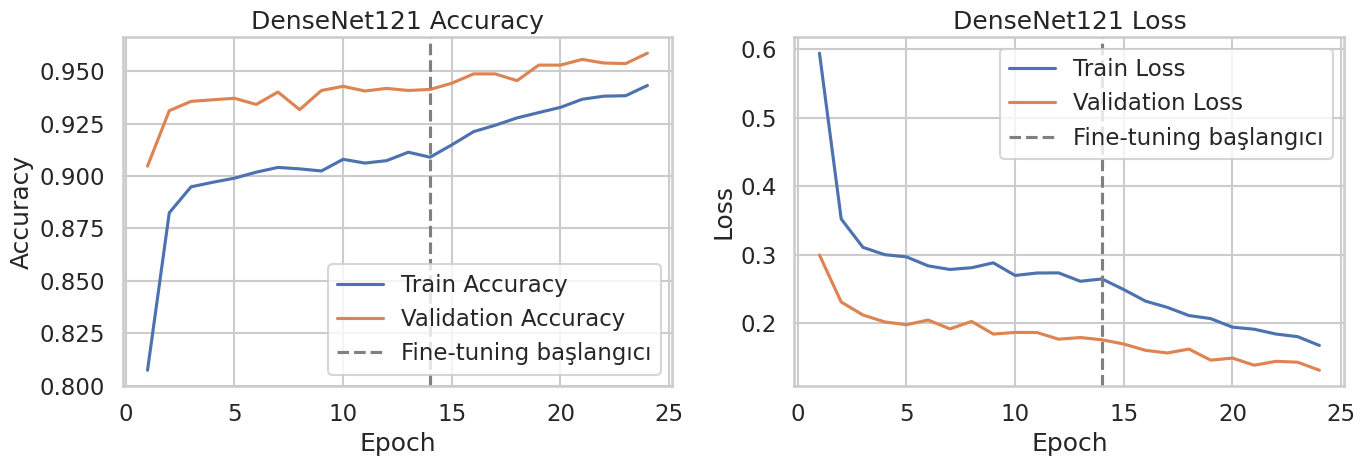

In [13]:
feature_epoch_count = len(history_feature.history["loss"])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["epoch"], history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation Accuracy")
plt.axvline(feature_epoch_count, color="gray", linestyle="--", label="Fine-tuning başlangıcı")
plt.title("DenseNet121 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["epoch"], history_df["loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.axvline(feature_epoch_count, color="gray", linestyle="--", label="Fine-tuning başlangıcı")
plt.title("DenseNet121 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "densenet121_accuracy_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## Eğitim eğrilerinin yorumu

Feature extraction aşamasında en iyi validation accuracy 0.9427 olarak elde edilmiştir. Fine-tuning sonrasında en iyi validation accuracy 0.9585 seviyesine yükselmiştir. Bu yaklaşık 1.6 yüzde puanlık artış, son DenseNet121 katmanlarının EuroSAT veri setine uyarlanmasının performansa katkı verdiğini göstermektedir.

Son epochta train accuracy 0.9431, validation accuracy ise 0.9585 değerindedir. Validation değerinin train değerinden yüksek görünmesi augmentation ve dropout etkisiyle açıklanabilir; eğitim sırasında model daha zorlaştırılmış örnekler görürken validation tarafı sabit görüntülerle ölçülmektedir.

Validation loss değerinin 0.1319 seviyesine kadar düşmesi, fine-tuning sonrasında modelin daha güvenli tahminler ürettiğini göstermektedir.

## Test kümesi değerlendirmesi

Test kümesi eğitim sırasında kullanılmamıştır. Bu nedenle final performans değerlendirmesi bu bölümde yapılmıştır. Validation kümesi modelin eğitim sürecini takip etmek için kullanılırken, test kümesi modelin daha tarafsız başarısını ölçmek için ayrılmıştır.

DenseNet121 modeli test kümesinde 0.9662 accuracy ve 0.1065 loss değerine ulaşmıştır. Bu sonuç, baseline CNN modeline göre yaklaşık 14.5 yüzde puanlık bir accuracy artışı sağlamaktadır. Ayrıca test loss değeri transfer learning modelleri arasında oldukça düşüktür.

In [15]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test loss değeri:", test_loss)
print("Test accuracy değeri:", test_accuracy)

254/254 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.9662 - loss: 0.1065
Test loss değeri: 0.10646116733551025
Test accuracy değeri: 0.9661728143692017


## Tahminlerin alınması

Classification report ve confusion matrix hesaplamak için test kümesindeki gerçek etiketler ile model tahminleri ayrı listelerde toplanmıştır. Model her görüntü için 10 sınıfa ait olasılık üretir. En yüksek olasılığa sahip sınıf tahmin edilen sınıf olarak alınmıştır.

In [16]:
y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Tahmin sayısı:", len(y_pred))

Tahmin sayısı: 4050


## Classification report

Accuracy tek başına yeterli değildir. Model genel olarak başarılı görünse bile bazı sınıflarda düşük performans gösterebilir. Bu nedenle precision, recall ve F1-score değerleri hesaplanmıştır.

Precision, modelin bir sınıf için yaptığı pozitif tahminlerin ne kadarının doğru olduğunu gösterir. Recall, o sınıfa ait gerçek örneklerin ne kadarının yakalandığını gösterir. F1-score ise precision ve recall değerlerini birlikte değerlendirir.

Macro ortalama her sınıfa eşit ağırlık verir. Weighted ortalama ise sınıf örnek sayılarını dikkate alır. EuroSAT tamamen eşit sınıflı olmadığı için iki ortalamanın birlikte verilmesi daha sağlıklı bir değerlendirme sağlar.

In [17]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(REPORTS_DIR / "densenet121_classification_report.csv", encoding="utf-8-sig")
report_df

,precision,recall,f1-score,support
AnnualCrop,0.968610,0.960000,0.964286,450.000000
Forest,0.978022,0.988889,0.983425,450.000000
HerbaceousVegetation,0.956140,0.968889,0.962472,450.000000
Highway,0.927835,0.960000,0.943644,375.000000
Industrial,0.973753,0.989333,0.981481,375.000000
Pasture,0.956522,0.953333,0.954925,300.000000
PermanentCrop,0.948925,0.941333,0.945114,375.000000
Residential,0.988764,0.977778,0.983240,450.000000
River,0.956164,0.930667,0.943243,375.000000
SeaLake,0.995485,0.980000,0.987682,450.000000


## Sınıf bazlı performans yorumu

Classification report incelendiğinde DenseNet121 modelinin tüm sınıflarda dengeli ve yüksek performans verdiği görülmektedir. En yüksek F1-score değerleri SeaLake (0.9877), Forest (0.9834), Residential (0.9832) ve Industrial (0.9815) sınıflarında elde edilmiştir.

En düşük F1-score değerleri River (0.9432), Highway (0.9436) ve PermanentCrop (0.9451) sınıflarındadır. Bu sınıflar modelin görece daha çok zorlandığı sınıflar olsa da F1-score değerleri hâlâ oldukça yüksektir. Baseline CNN'de Highway F1-score değeri 0.5989 iken DenseNet121'de 0.9436'ya yükselmiştir.

Macro F1-score değeri 0.9650, weighted F1-score değeri ise 0.9662 olarak hesaplanmıştır. Bu değerler DenseNet121'in yalnızca genel accuracy bakımından değil, sınıf bazlı denge bakımından da güçlü olduğunu göstermektedir.

## Confusion matrix

Confusion matrix, modelin hangi sınıfları hangi sınıflarla karıştırdığını gösterir. Satırlar gerçek sınıfları, sütunlar tahmin edilen sınıfları temsil eder.

Bu analiz özellikle hata yorumları için önemlidir. Örneğin model PermanentCrop görüntülerini AnnualCrop olarak tahmin ediyorsa, bu iki sınıfın görsel benzerliği raporda tartışılabilir.

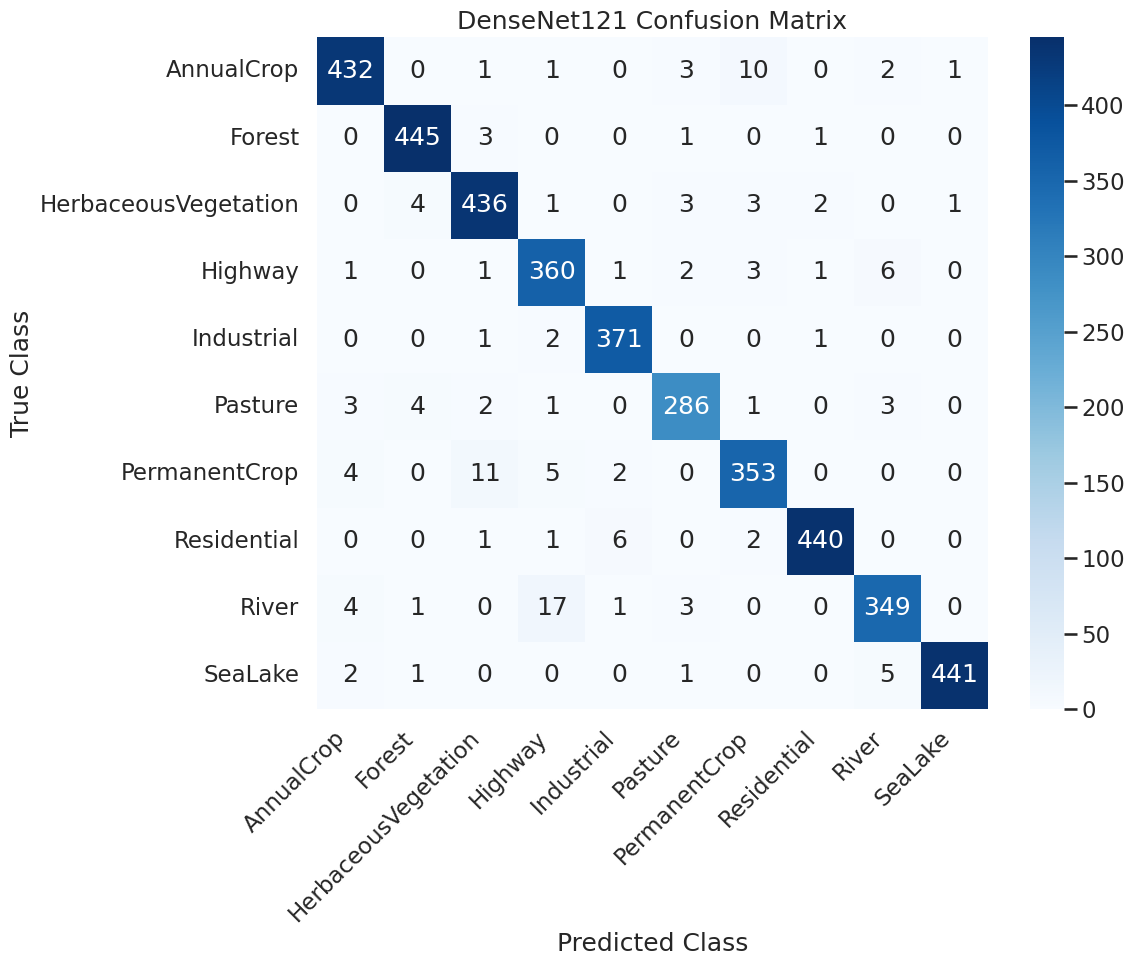

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("DenseNet121 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "densenet121_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Confusion matrix yorumu

Confusion matrix çıktısı, DenseNet121 modelinde hataların baseline CNN'e göre büyük ölçüde azaldığını göstermektedir. Classification reportta en düşük F1-score değerinin bile 0.9432 olması, modelin zayıf kaldığı sınıflarda dahi kabul edilebilir düzeyin üzerinde performans verdiğini gösterir.

River, Highway ve PermanentCrop sınıfları hâlâ en düşük F1-score değerlerine sahiptir. Bu durum görsel olarak benzer çizgisel yapılar ve tarımsal dokuların tamamen ortadan kalkmayan bir hata kaynağı olduğunu göstermektedir. Buna rağmen DenseNet121, bu sınıflarda baseline CNN'e göre belirgin bir iyileşme sağlamıştır.

## Sonuçları kaydetme

Bu bölümde DenseNet121 modeline ait temel sonuçlar dosyaya kaydedilmiştir. Kaydedilen dosyalar final karşılaştırma notebookunda tekrar okunacaktır.

Kaydedilen bilgiler:

1. Test accuracy ve test loss değerleri
2. Balanced accuracy
3. Macro ve weighted precision, recall, F1-score değerleri
4. Feature extraction ve fine-tuning eğitim süreleri
5. En iyi validation accuracy değerleri
6. Classification report tablosu
7. Eğitim geçmişi
8. En iyi model ağırlıkları

Bu kayıt yapısı, sonuçların sonradan rapora aktarılmasını ve modeller arasında adil karşılaştırma yapılmasını kolaylaştırır.

In [19]:
summary_metrics = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
    "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    "weighted_precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
    "weighted_recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
    "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
}

metrics = {
    "model": "DenseNet121",
    "method": "transfer_learning_and_fine_tuning",
    "augmentation_type": "geometric",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "feature_validation_loss": float(feature_val_loss),
    "feature_validation_accuracy": float(feature_val_accuracy),
    "best_feature_val_accuracy": float(max(history_feature.history["val_accuracy"])),
    "best_finetune_val_accuracy": float(max(history_fine.history["val_accuracy"])),
    "feature_epochs_ran": int(len(history_feature.history["loss"])),
    "fine_tune_epochs_ran": int(len(history_fine.history["loss"])),
    "feature_training_time_seconds": float(feature_training_time),
    "fine_tuning_time_seconds": float(fine_tuning_time),
    "total_training_time_seconds": float(feature_training_time + fine_tuning_time),
    "total_params": int(model.count_params()),
    "trainable_params_after_finetuning": int(sum(np.prod(weight.shape) for weight in model.trainable_weights)),
    "fine_tune_trainable_layers": int(trainable_layers),
    "num_classes": int(num_classes),
    "class_names": class_names,
    "dataset_sizes": dataset_sizes,
    **summary_metrics,
}

metrics_path = REPORTS_DIR / "densenet121_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")

history_df.to_csv(REPORTS_DIR / "densenet121_history.csv", index=False, encoding="utf-8-sig")
model.save(MODELS_DIR / "densenet121_final.keras")

pd.DataFrame([metrics])

,model,method,augmentation_type,test_loss,test_accuracy,feature_validation_loss,feature_validation_accuracy,best_feature_val_accuracy,best_finetune_val_accuracy,feature_epochs_ran,...,class_names,dataset_sizes,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,DenseNet121,transfer_learning_and_fine_tuning,geometric,0.106461,0.966173,0.186947,0.942716,0.942716,0.958519,14,...,"[AnnualCrop, Forest, HerbaceousVegetation, Hig...","{'train': 18900, 'valid': 4050, 'test': 4050}",0.966173,0.965022,0.965022,0.965022,0.964951,0.966326,0.966173,0.96618


## DenseNet121 notebook özeti

Bu notebookta DenseNet121 modeli ile transfer learning ve fine-tuning uygulanmıştır. Model 7.047.754 parametreye sahiptir ve fine-tuning sonrasında 1.071.114 parametre eğitilebilir hale gelmiştir.

Feature extraction aşamasında validation accuracy 0.9427, fine-tuning sonrasında en iyi validation accuracy 0.9585 olarak elde edilmiştir. Test kümesinde ise 0.9662 accuracy, 0.9650 macro F1-score ve 0.9662 weighted F1-score değerlerine ulaşılmıştır.

Bu sonuçlar DenseNet121'in şu ana kadarki modeller içinde en güçlü genel performansı verdiğini göstermektedir. Özellikle tüm sınıflarda F1-score değerlerinin 0.94 üzerinde kalması, modelin yalnızca bazı kolay sınıflarda değil, zor sınıflarda da başarılı olduğunu göstermektedir.